# Loading and Pre Processing

In [29]:
import torchvision
from torchvision import transforms
import torch
import torch.nn as nn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.backends.cudnn.benchmark = True

In [30]:
img_path = './'
transform = transforms.Compose([transforms.ToTensor()])
mnist_dataset = torchvision.datasets.MNIST(root=img_path,train=True,transform = transform,download=True)


In [31]:
from torch.utils.data import Subset
mnist_valid_dataset = Subset(mnist_dataset,torch.arange(10000))
mnist_train_dataset = Subset(mnist_dataset,torch.arange(10000,len(mnist_dataset)))
mnist_test_dataset = torchvision.datasets.MNIST( root=img_path, train=False,transform=transform, download=False)


In [32]:
from torch.utils.data import DataLoader

batch_size = 64
torch.manual_seed(1)
train_dl = DataLoader(mnist_train_dataset,batch_size,shuffle=True)
valid_dl = DataLoader(mnist_valid_dataset,batch_size,shuffle=False)

# Adding layers in the CNN

In [33]:
model = nn.Sequential()
model.add_module('conv1',nn.Conv2d(in_channels=1,out_channels=32,kernel_size=5,padding=2))
model.add_module('relu1',nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(kernel_size=2))
model.add_module('conv2',nn.Conv2d(in_channels=32,out_channels=64,kernel_size=5,padding=2))
model.add_module('relu2',nn.ReLU())
model.add_module('pool2', nn.MaxPool2d(kernel_size=2))


# manually finding size of feature matrix at this point

In [34]:
model.add_module('flatten',nn.Flatten())
model.add_module('fc1',nn.Linear(3136,1024))
model.add_module('relu3', nn.ReLU())
model.add_module('dropput',nn.Dropout(p=0.5))
model.add_module('fc2',nn.Linear(1024,10))
model.to(device)

Sequential(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=1024, bias=True)
  (relu3): ReLU()
  (dropput): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=1024, out_features=10, bias=True)
)

In [35]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001) 


In [36]:
def train(model,num_epochs,train_dl,valid_dl):
    loss_hist_train = [0]*num_epochs
    accuracy_hist_train = [0]*num_epochs
    loss_hist_valid = [0]*num_epochs
    accuracy_hist_valid = [0]*num_epochs
    for epochs in range(num_epochs):
        model.train()
        for x_batch,y_batch in train_dl:
            x_batch = x_batch.to(device) 
            y_batch = y_batch.to(device)
            pred = model(x_batch)
            loss = loss_fn(pred,y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_hist_train[epochs] +=loss.item()*y_batch.size(0)
            is_correct = (torch.argmax(pred,dim=1)==y_batch).float()
            accuracy_hist_train[epochs] += is_correct.sum()
        loss_hist_train[epochs] /= len(train_dl.dataset)
        accuracy_hist_train[epochs] /= len(train_dl.dataset)

        model.eval()

        with torch.no_grad():
            for x_batch, y_batch in valid_dl:
                x_batch = x_batch.to(device) 
                y_batch = y_batch.to(device)
                pred = model(x_batch)
                loss = loss_fn(pred,y_batch)
            
                loss_hist_valid[epochs] +=loss.item()*y_batch.size(0)
                is_correct = (torch.argmax(pred,dim=1)==y_batch).float()
                accuracy_hist_valid[epochs] += is_correct.sum()
        loss_hist_valid[epochs] /= len(valid_dl.dataset)
        accuracy_hist_valid[epochs] /= len(valid_dl.dataset)

        print(f'Epoch {epochs+1} accuracy: 'f'{accuracy_hist_train[epochs]:.4f} val_accuracy: 'f'{accuracy_hist_valid[epochs]:.4f}')

    return loss_hist_train,loss_hist_valid,accuracy_hist_train,accuracy_hist_valid

In [37]:
torch.manual_seed(1)
num_epochs= 20
hist = train(model, num_epochs, train_dl, valid_dl)

Epoch 1 accuracy: 0.9501 val_accuracy: 0.9822
Epoch 2 accuracy: 0.9841 val_accuracy: 0.9863
Epoch 3 accuracy: 0.9896 val_accuracy: 0.9833
Epoch 4 accuracy: 0.9916 val_accuracy: 0.9893
Epoch 5 accuracy: 0.9937 val_accuracy: 0.9897
Epoch 6 accuracy: 0.9945 val_accuracy: 0.9903
Epoch 7 accuracy: 0.9951 val_accuracy: 0.9898
Epoch 8 accuracy: 0.9960 val_accuracy: 0.9907
Epoch 9 accuracy: 0.9967 val_accuracy: 0.9890
Epoch 10 accuracy: 0.9969 val_accuracy: 0.9903
Epoch 11 accuracy: 0.9970 val_accuracy: 0.9904
Epoch 12 accuracy: 0.9972 val_accuracy: 0.9907
Epoch 13 accuracy: 0.9975 val_accuracy: 0.9909
Epoch 14 accuracy: 0.9973 val_accuracy: 0.9927
Epoch 15 accuracy: 0.9984 val_accuracy: 0.9909
Epoch 16 accuracy: 0.9983 val_accuracy: 0.9911
Epoch 17 accuracy: 0.9979 val_accuracy: 0.9875
Epoch 18 accuracy: 0.9977 val_accuracy: 0.9902
Epoch 19 accuracy: 0.9988 val_accuracy: 0.9902
Epoch 20 accuracy: 0.9983 val_accuracy: 0.9892


# Visualizing the Leaning Curve

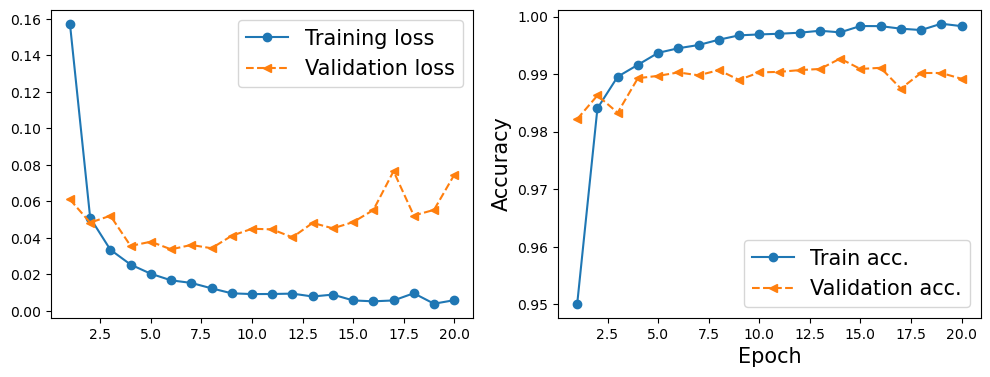

In [38]:
import matplotlib.pyplot as plt
import numpy as np
x_arr = np.arange(len(hist[0])) + 1
train_acc = np.array([v.detach().cpu().item() for v in hist[2]])
valid_acc = np.array([v.detach().cpu().item() for v in hist[3]])

fig = plt.figure(figsize=(12,4))
ax = fig.add_subplot(1,2,1)
ax.plot(x_arr,hist[0],'-o',label="Training loss")
ax.plot(x_arr,hist[1],'--<',label="Validation loss")
ax.legend(fontsize=15)
ax = fig.add_subplot(1,2,2)
ax.plot(x_arr, train_acc, '-o', label='Train acc.')
ax.plot(x_arr, valid_acc, '--<',label='Validation acc.')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Accuracy', size=15)
plt.show()

# Evaluate Model On Test Data

Test accuracy: 0.9916


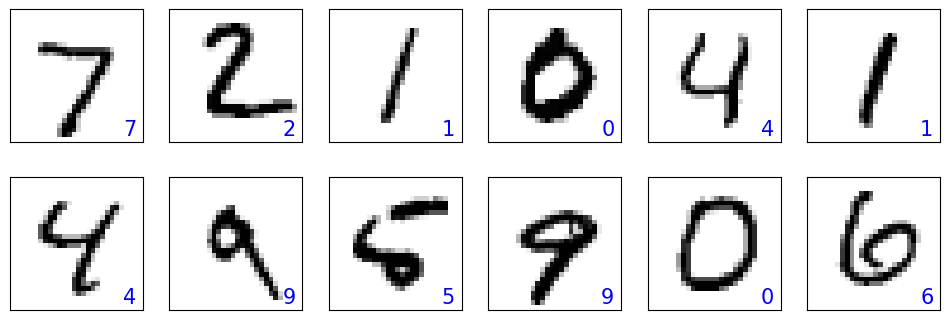

In [39]:
model.eval()
with torch.no_grad():
    
    test_data = mnist_test_dataset.data.unsqueeze(1).float().to(device) / 255.
    test_targets = mnist_test_dataset.targets.to(device)
    
    pred = model(test_data)
    is_correct = (torch.argmax(pred, dim=1) == test_targets).float()
    print(f'Test accuracy: {is_correct.mean():.4f}')


fig = plt.figure(figsize=(12, 4))
model.eval()
with torch.no_grad():
    for i in range(12):
        ax = fig.add_subplot(2, 6, i+1)
        ax.set_xticks([])
        ax.set_yticks([])
        img = mnist_test_dataset[i][0][0, :, :]
        
        
        img_tensor = mnist_test_dataset[i][0].unsqueeze(0).to(device)
        pred = model(img_tensor)
        y_pred = torch.argmax(pred)
        
        ax.imshow(img, cmap='gray_r')  
        ax.text(0.9, 0.1, y_pred.item(),
                size=15, color='blue',
                horizontalalignment='center',
                verticalalignment='center',
                transform=ax.transAxes)
plt.show()